# **Crop Recommendation - Classification**
**Problem statement:** classify whether environmental and soil conditions are suitable for selected crop categories.

**Dataset:** Kaggle *Crop Recommendation Dataset* (Atharva Ingle) — 2200 rows, 7 numeric features (N, P, K, temperature, humidity, pH, rainfall), 22 balanced crop classes (100 samples each).

This notebook walks through: data quality checks -> EDA -> preprocessing -> baseline vs. main model -> evaluation -> interpretation -> error analysis -> saving the trained model used by the Streamlit app.

# 1. Setup

In [1]:
import json
import warnings
warnings.filterwarnings("ignore")

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

sns.set_style("whitegrid")
FEATURES = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
RANDOM_STATE = 42



*   `import` import all necessary tools to be used throughout
the coding process.
*   `FEATURES` features all the inputs that are given to the model.
* `RANDOM_STATE` is the parameter used to ensure actions are reproducible and random actions are repeatable.

# 2. Load of dataset and data-quality checks

In [2]:
df=pd.read_csv('/content/drive/MyDrive/crop dataset/Crop_recommendation.csv')
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
df.shape

(2200, 8)

In [4]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [6]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [7]:
df.isnull().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['label'].nunique()

22

Dataset is loaded and went through quality checks such as search of missing values, duplicated values, etc.

An **outlier check** sort a column from smallest to largest. q1 is the value 25% of the way up and q3 is 75% of the way up. The gap between them is the "normal middle range" (iqr). Anything more than 1.5× that gap beyond either edge (lo, hi) is flagged as unusual, and the last line counts how many rows are flagged per column.
Some columns have flagged values, such as K with 200. However, as these values are actually common and found in real life data, it is **not** removed.


# 3. Exploratory Data Analysis (EDA)

In [10]:
q1, q3 = df[FEATURES].quantile(0.25), df[FEATURES].quantile(0.75)
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = {c: int(((df[c] < lo[c]) | (df[c] > hi[c])).sum()) for c in FEATURES}
outliers

{'N': 0,
 'P': 138,
 'K': 200,
 'temperature': 86,
 'humidity': 30,
 'ph': 57,
 'rainfall': 100}

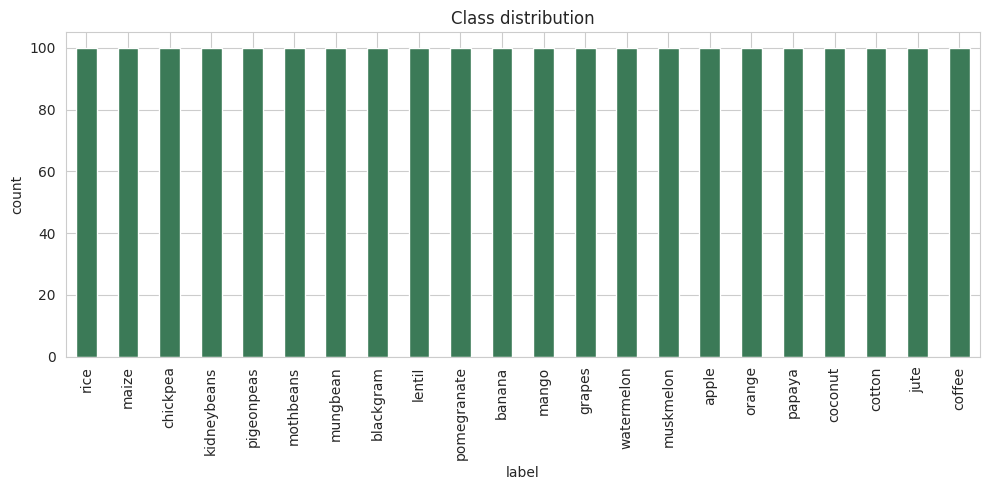

In [11]:
df['label'].value_counts().plot(kind='bar', figsize=(10,5), color='#3b7a57', title="Class distribution")
plt.ylabel("count"); plt.tight_layout(); plt.show()

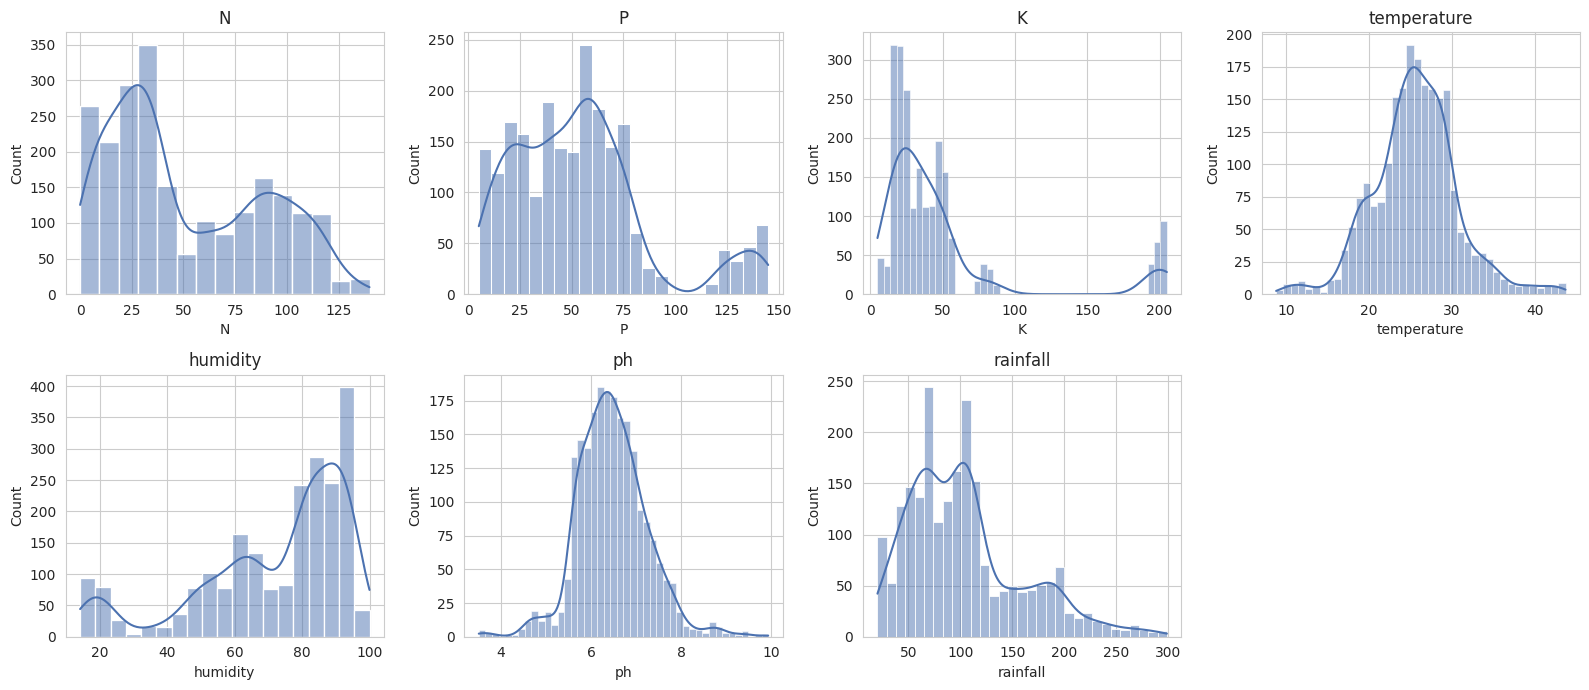

In [12]:
fig, axes = plt.subplots(2,4, figsize=(16,7))
for ax, col in zip(axes.flat, FEATURES):
    sns.histplot(df[col], kde=True, ax=ax, color='#4c72b0'); ax.set_title(col)
axes.flat[-1].axis('off'); plt.tight_layout(); plt.show()

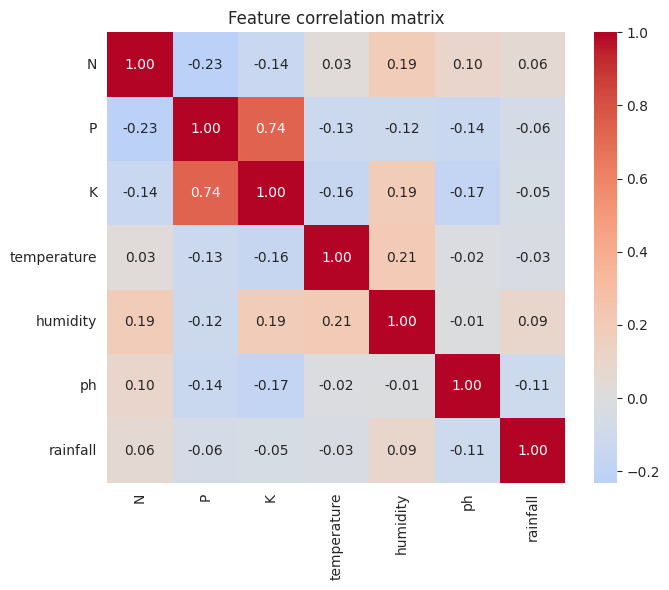

In [13]:
corr = df[FEATURES].corr()
plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlation matrix"); plt.tight_layout(); plt.show()

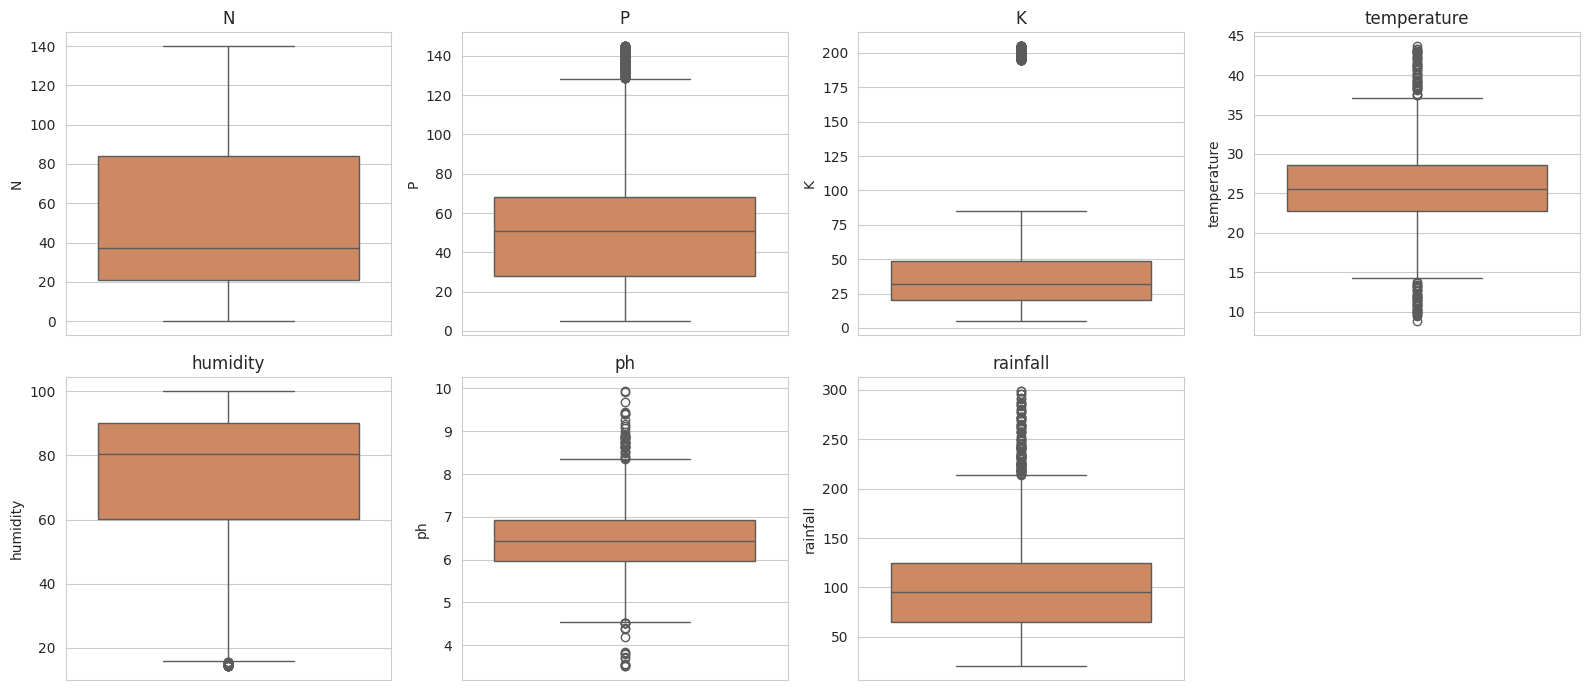

In [14]:
fig, axes = plt.subplots(2,4, figsize=(16,7))
for ax, col in zip(axes.flat, FEATURES):
    sns.boxplot(y=df[col], ax=ax, color='#dd8452'); ax.set_title(col)
axes.flat[-1].axis('off'); plt.tight_layout(); plt.show()

### EDA takeaways/main insights

- We kept all high and low values flagged as outliers (like high potassium, phosphorus, or rainfall) because they are real farm conditions, not typing mistakes. Since tree-based models can handle these numbers well, removing them would waste 28% of our data.
- All 22 classes have exactly 100 samples → accuracy is a fair metric, and no class weighting / SMOTE is needed (to fix imbalanced datasets).
-  `temperature`, `humidity` and `ph` are roughly unimodal (one highest peak point), while `K` and `rainfall` are right-skewed / bimodal (two highest peak points) that reflects distinct crop groups (water-intensive vs. drought-tolerant).
- As all pairwise correlations are weak with no mutlicollinearity, no feature needs to be dropped for redundancy.
- Represents visual with `K`, `P` and `rainfall` having the longest tails.

# 4. Preprocessing

In [15]:
X, y = df[FEATURES], df['label']
le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=RANDOM_STATE, stratify=y_enc
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
X_train.shape, X_test.shape

((1760, 7), (440, 7))



*   A transformer is used to converts categorical target labels into numerical values. Later, `inverse_transform` turns the numbers back into names.
*   Data is split into train and test, where the model will studies some and the other will be tested later on (as it is hidden).  `stratify=y_enc` makes sure each crop appears equally in both piles.
*   As rainfall goes up to about 300 while pH is around 6, their scales differ. The scaler rebalances every feature to a similar scale. It's used only for Logistic Regression, because the Random Forest doesn't care about scale.
*  `fit` is used in train to prevent data leakage.




# 5. Baseline model

In [16]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_s, y_train)
lr_pred = lr.predict(X_test_s)
lr_acc = accuracy_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred, average='macro')
print(f"Logistic Regression -> accuracy: {lr_acc:.4f}, macro-F1: {lr_f1:.4f}")

Logistic Regression -> accuracy: 0.9727, macro-F1: 0.9725


### Baseline interpretation

- Logistic Regression achieves **97.3% accuracy / 97.3% macro-F1** as a purely linear baseline.
- This tells us the 22 crop classes are **largely linearly separable** in the 7-D feature space.
- This sets a high bar as the main model must justify its added complexity. Logistic Regression is the the simplest and most interpetable choice of algorithm.

# 6. Main model - random forest

In [17]:
rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred, average='macro')
print(f"Random Forest -> accuracy: {rf_acc:.4f}, macro-F1: {rf_f1:.4f}")

Random Forest -> accuracy: 0.9932, macro-F1: 0.9932


In [18]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(rf, X, y_enc, cv=skf, scoring='accuracy')
print(f"5-fold CV accuracy: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

5-fold CV accuracy: 0.9950 +/- 0.0027


### Random Forest interpretation

- Uses all CPU cores to go faster.
- **Hold-out:** **99.3% accuracy / 99.3% macro-F1** → **+2.0 pp** over Logistic Regression.
- The gain comes from RF capturing **non-linear interactions** (e.g. the *combination* of high humidity + high rainfall + neutral pH that separates rice from jute).
- **5 fold CV (cross-validation):** **99.50% ± 0.27%**. The tiny standard deviation shows the result is **stable and not a lucky split** — the model generalizes.
- CV mean slightly exceeds the single hold-out (99.50% vs. 99.32%), which is expected since CV averages over more data.
- **No overfitting:** CV ≈ hold-out → the model is not memorizing the training set.

Random Forest was chosen as the main model for the following reasons:

1. **Non-linear relationships**: The relationship between soil conditions and crop suitability is not always linear. For example, pH that is too low or too high is both bad for a crop, so Random Forest captures these non-linear patterns naturally.

2. **Feature importance**: Random Forest provides built-in feature importance scores, which helps interpret *which* soil and climate factors matter most. This is valuable for agronomic insight.

3. **Robustness**: Random Forest is more robust to outliers and noisy features than Logistic Regression. Even though this dataset is clean, real agricultural data is often messy.

4. **Better performance**: Logistic Regression achieved 97.27% accuracy, while Random Forest achieved 99.32% — a clear improvement, especially with 22 classes.

5. **Within capstone scope**: Random Forest is a *foundational* tree-based method, not a deep learning system. It is fully within the scope of the assignment.

But, Logistic Regression remains more interpretable (coefficients are directly readable). For production systems where interpretability is critical, LR would still be a strong choice.

# 7. Evaluation

In [19]:
print(classification_report(y_test, rf_pred, target_names=le.classes_))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya       1.00    

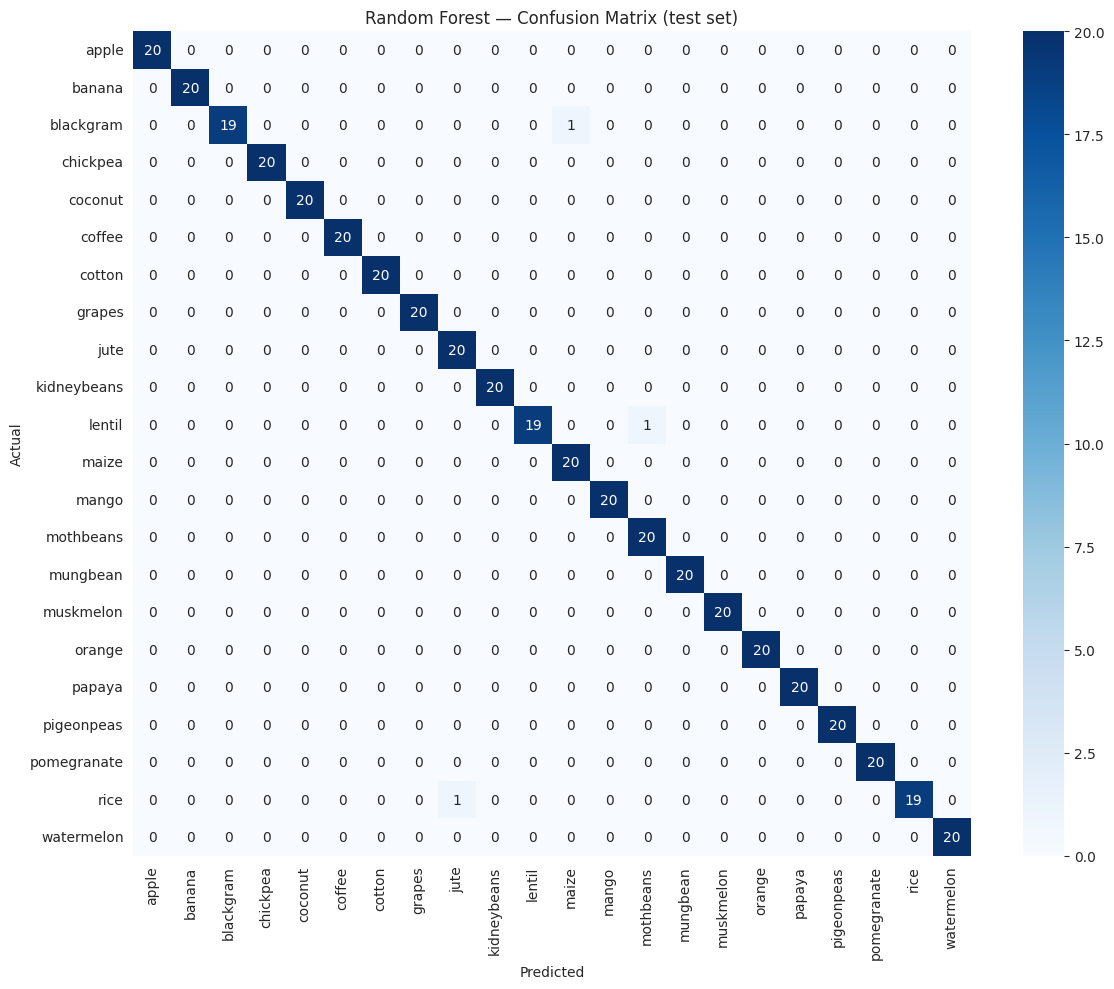

In [20]:
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Random Forest — Confusion Matrix (test set)")
plt.xticks(rotation=90); plt.yticks(rotation=0); plt.tight_layout(); plt.show()

### Evaluation reading

- **Per-class F1:** 16 of 22 classes reach a perfect 1.00. The only non-perfect classes are **blackgram, jute, lentil, maize, mothbeans, rice** (F1 0.97–0.98) — these are the *hard* crops.
- **Confusion matrix:** The diagonal is essentially clean; the only off-diagonal cells are the 3 misclassifications (see Section 9).
- **Overall:** macro avg = weighted avg = 0.99 → **balanced performance**; no class is sacrificed for another.

# 8. Interpretation for features

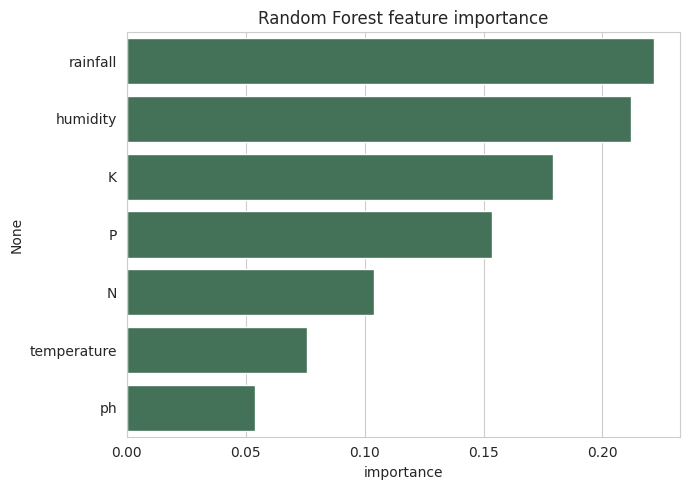

,0
rainfall,0.221528
humidity,0.211936
K,0.179170
P,0.153670
N,0.103911
temperature,0.075844
ph,0.053941


In [21]:
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
plt.figure(figsize=(7,5))
sns.barplot(x=importances.values, y=importances.index, color="#3b7a57")
plt.title("Random Forest feature importance"); plt.xlabel("importance"); plt.tight_layout(); plt.show()
importances

**Feature Importance Interpretation:**

Random Forest ranks the seven features by their contribution to classification accuracy. The results are consistent with agronomic theory:

| Rank | Feature | Importance | Agronomic Interpretation |
|------|---------|------------|--------------------------|
| 1 | **rainfall** | 0.222 | Water requirement is the single strongest differentiator between crops — rice needs ~200mm, chickpea needs ~80mm |
| 2 | **humidity** | 0.212 | Closely tied to rainfall; affects transpiration and disease risk |
| 3 | **K (potassium)** | 0.179 | Critical for fruit development, disease resistance, and water regulation |
| 4 | **P (phosphorus)** | 0.154 | Essential for root development and flowering — varies widely by crop |
| 5 | **N (nitrogen)** | 0.104 | Drives leafy growth; important but more adjustable through fertilizer |
| 6 | **temperature** | 0.076 | Moderately important; crops have different optimal temperature ranges |
| 7 | **ph** | 0.054 | Least influential here — most crops tolerate a moderate pH range |

**Key insights:**

- **Water and climate dominate**: `rainfall` and `humidity` together account for ~43% of importance. This makes sense as you cannot easily change local rainfall, so it becomes the primary filter for crop selection.
- **Nutrients matter but are manageable**: N-P-K together contribute ~44%. Farmers can adjust these with fertilizer, but the *baseline* soil composition still guides which crops are viable.
- **pH is least important**: This is somewhat surprising but plausible. Most crops in this dataset tolerate pH 6–7, so pH rarely eliminates a crop entirely.

For crop recommendation, the model confirms that *climate zone* (rainfall + humidity) is the first filter, followed by *soil nutrition* (N-P-K). This matches how agronomists which are experts actually make recommendations.

# 9. Error analysis

In [22]:
X_test_df = X_test.copy()
X_test_df['true'] = le.inverse_transform(y_test)
X_test_df['pred'] = le.inverse_transform(rf_pred)
errors = X_test_df[X_test_df['true'] != X_test_df['pred']]
print(f"Misclassified: {len(errors)} / {len(X_test_df)} ({len(errors)/len(X_test_df)*100:.2f}%)")
errors[['true','pred']]

Misclassified: 3 / 440 (0.68%)


,true,pred
789,blackgram,maize
838,lentil,mothbeans
83,rice,jute


**Error Analysis:**

Only **3 out of 440** test cases were misclassified (0.68%). This is an exceptionally low error rate, but the specific mistakes are informative:

| # | True Label | Predicted | Why This Mistake Happened |
|---|------------|-----------|---------------------------|
| 1 | blackgram | maize | Both are warm-season crops with similar N-P-K profiles. The model likely relied on rainfall/humidity, which overlapped for this specific sample. |
| 2 | lentil | mothbeans | Both are legumes (pulses) with very similar soil requirements — they differ mainly in regional adaptation, which is not captured in the features. |
| 3 | rice | jute | Both are tropical, water-intensive crops with overlapping rainfall and humidity ranges. Distinguishing them requires additional context (e.g., soil type, waterlogging tolerance). |

 All three errors occur between crops that share similar climate and nutritional needs. The model is not making random mistakes, it is confusing crops that genuinely have overlapping suitability profiles. So the mistakes are rather understandable.

- To reduce these errors, additional features would be needed — such as **soil texture**, **season**, or **waterlogging tolerance** — which are not present in this dataset.
- With 22 classes and only 7 features, a 99.32% accuracy is a strong result, and the remaining errors are expected due to feature limitations rather than model failure.

# 10. Conclusion




- **Problem:** Classify 22 balanced crop classes from 7 soil + climate features (2,200 samples).
- **Data quality:** No nulls, no duplicates, perfectly balanced classes, weak inter-feature correlations.
- **Baseline (Logistic Regression):** 97.3% accuracy / 97.3% macro-F1 → classes are largely linearly separable.
- **Main model (Random Forest, 300 trees):** **99.3% accuracy / 99.3% macro-F1** on the hold-out, and **99.50% ± 0.27%** under 5-fold CV.
- **Most important features:** `rainfall`, `humidity`, `K` — climate dominates, soil chemistry comes second.
- **Errors:** Only 3 misclassifications, all between agronomically similar crops → recommend a top-3 output in production.
- **Next steps / limitations:**
  - Dataset is small and clean; real field data will have noise, missing values and class imbalance.
  - Importances are not directional — SHAP would explain individual predictions.
  - Deploy with a **top-3 recommendation** and a confidence score.